In [1]:
"""
Paper-2 Methodology: CA-ANN based LULC Prediction
- Cellular Automata (CA) for spatial transition modeling
- Artificial Neural Network (ANN) with ReLU + Softmax
- Drivers: elevation, slope, proximity (roads, water, metro, railway), EOIs (NDVI, NDBI, MNDWI), population, precipitation
- Pearson Correlation for driver selection
- Validation: Kappa, OA, Quantity/Allocation Disagreement
"""

import numpy as np
import pandas as pd
import rasterio
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score
from scipy.stats import pearsonr
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Base paths
BASE = r'Urban_model_landsat'
CLASS_NAMES = ['Built-up', 'Vegetation', 'Bare Land', 'Water']
N_CLASSES = 4

print("Setup complete.")


Setup complete.


In [2]:
def load_raster(path):
    """Load a single-band raster and return data, transform, meta."""
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32), src.transform, src.meta

# Load classified LULC maps for 3 time periods
lulc_2005_raw, transform_2005, meta_2005 = load_raster(f'{BASE}/classified_2005.tif')
lulc_2015_raw, transform_2015, meta_2015 = load_raster(f'{BASE}/classified_2015.tif')
lulc_2025_raw, transform_2025, meta_2025 = load_raster(f'{BASE}/classified_2025.tif')

# Align to common dimensions (crop to smallest)
target_h = min(lulc_2005_raw.shape[0], lulc_2015_raw.shape[0], lulc_2025_raw.shape[0])
target_w = min(lulc_2005_raw.shape[1], lulc_2015_raw.shape[1], lulc_2025_raw.shape[1])

lulc_2005 = lulc_2005_raw[:target_h, :target_w].copy()
lulc_2015 = lulc_2015_raw[:target_h, :target_w].copy()
lulc_2025 = lulc_2025_raw[:target_h, :target_w].copy()

# Create valid mask — exclude nodata (255) and keep only classes 1–4
valid_mask = (lulc_2005 != 255) & (lulc_2005 >= 1) & (lulc_2005 <= N_CLASSES)
valid_mask &= (lulc_2015 >= 1) & (lulc_2015 <= N_CLASSES)
valid_mask &= (lulc_2025 >= 1) & (lulc_2025 <= N_CLASSES)

lulc_2005[~valid_mask] = 0
lulc_2015[~valid_mask] = 0
lulc_2025[~valid_mask] = 0

print(f"Raster shape: {target_h} x {target_w}")
print(f"Valid pixels: {valid_mask.sum():,} / {target_h * target_w:,} ({valid_mask.mean()*100:.1f}%)")
print(f"LULC classes found: {np.unique(lulc_2015[valid_mask])}")


Raster shape: 2068 x 2268
Valid pixels: 4,690,224 / 4,690,224 (100.0%)
LULC classes found: [1. 2. 3. 4.]


In [3]:
# Static drivers (same across time periods) — per paper: proximity, elevation
static_driver_paths = [
    (f'{BASE}/Elevation.tif',            'Elevation'),
    (f'{BASE}/Slope.tif',                'Slope'),
    (f'{BASE}/Distance_metro.tif',       'Dist_Metro'),
    (f'{BASE}/EucDist_PrimaryRoad.tif',  'Dist_PrimaryRd'),
    (f'{BASE}/EucDist_railwaySt.tif',    'Dist_RailwaySt'),
    (f'{BASE}/EucDist_roadnetwork.tif',  'Dist_RoadNet'),
    (f'{BASE}/EucDist_secondaryRoads.tif','Dist_SecondaryRd'),
    (f'{BASE}/EucDist_waterbody.tif',    'Dist_Waterbody'),
]

# Time-varying drivers (EOIs + population + precip) — per paper Sec 3.4.2
def load_temporal_drivers(period_folder):
    return [
        (f'{BASE}/{period_folder}/NDVI.tif',          'NDVI'),
        (f'{BASE}/{period_folder}/NDBI.tif',          'NDBI'),
        (f'{BASE}/{period_folder}/MNDWI.tif',         'MNDWI'),
        (f'{BASE}/{period_folder}/population.tif',     'Population'),
        (f'{BASE}/{period_folder}/precipitation.tif',  'Precipitation'),
    ]

def load_driver_stack(static_paths, temporal_paths, h, w):
    """Load all drivers, crop to (h, w), stack into array."""
    all_data, all_names = [], []
    for path, name in static_paths + temporal_paths:
        d, _, _ = load_raster(path)
        d = d[:h, :w]
        d[d < 0] = 0  # replace negative nodata
        d = np.nan_to_num(d, nan=0.0)
        all_data.append(d)
        all_names.append(name)
    stack = np.stack(all_data, axis=-1)
    # MinMax normalization to [0,1] as per paper
    scaler = MinMaxScaler()
    flat = stack.reshape(-1, stack.shape[-1])
    norm = scaler.fit_transform(flat).reshape(stack.shape)
    return norm, all_names, scaler

# Load for training period (2005 drivers → predict 2015)
driver_norm_2005, driver_names, scaler_2005 = load_driver_stack(
    static_driver_paths, load_temporal_drivers('drivers_2005'), target_h, target_w
)
# Load for projection period (2015 drivers → predict 2025+)
driver_norm_2015, _, scaler_2015 = load_driver_stack(
    static_driver_paths, load_temporal_drivers('drivers_2015'), target_h, target_w
)

n_drivers = len(driver_names)
print(f"Driver stack shape: {driver_norm_2005.shape}")
print(f"Drivers ({n_drivers}): {driver_names}")


Driver stack shape: (2068, 2268, 13)
Drivers (13): ['Elevation', 'Slope', 'Dist_Metro', 'Dist_PrimaryRd', 'Dist_RailwaySt', 'Dist_RoadNet', 'Dist_SecondaryRd', 'Dist_Waterbody', 'NDVI', 'NDBI', 'MNDWI', 'Population', 'Precipitation']


=== Driver-LULC Correlations (2005) ===
          Driver       PCC       p-value    |PCC|
      Population -0.250664  0.000000e+00 0.250664
      Dist_Metro  0.225502  0.000000e+00 0.225502
   Precipitation -0.169390  0.000000e+00 0.169390
  Dist_RailwaySt  0.167476  0.000000e+00 0.167476
  Dist_Waterbody  0.163300  0.000000e+00 0.163300
           Slope -0.087031  0.000000e+00 0.087031
Dist_SecondaryRd  0.061546  0.000000e+00 0.061546
  Dist_PrimaryRd  0.048880  0.000000e+00 0.048880
    Dist_RoadNet  0.011662 9.633685e-141 0.011662
       Elevation  0.007636  2.000495e-61 0.007636
           MNDWI  0.002996  8.618423e-11 0.002996
            NDVI  0.002793  1.453275e-09 0.002793
            NDBI       NaN           NaN      NaN

=== Driver-LULC Correlations (2015) ===
          Driver       PCC      p-value    |PCC|
      Dist_Metro  0.268254 0.000000e+00 0.268254
      Population -0.266942 0.000000e+00 0.266942
  Dist_RailwaySt  0.227175 0.000000e+00 0.227175
  Dist_Waterbody  0.215

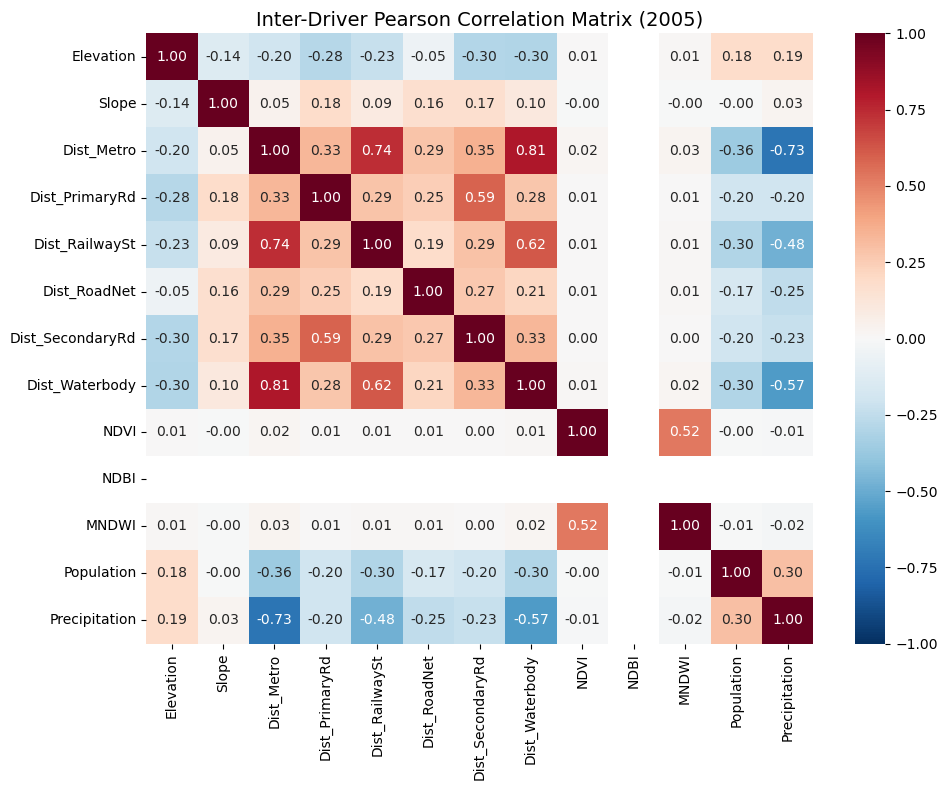


Saved: driver_correlation.png


In [4]:
# Paper Sec 3.4.1: PCC analysis to select predictors and explore
# relationships among EOIs, LULC, and thermal indices

def compute_driver_correlations(driver_stack, lulc_map, mask, driver_names):
    """Compute Pearson correlation between each driver and LULC."""
    lulc_flat = lulc_map[mask].flatten()
    results = []
    for i, name in enumerate(driver_names):
        d_flat = driver_stack[:, :, i][mask].flatten()
        r, p = pearsonr(d_flat, lulc_flat)
        results.append({'Driver': name, 'PCC': r, 'p-value': p, '|PCC|': abs(r)})
    return pd.DataFrame(results).sort_values('|PCC|', ascending=False)

# Correlation for each time period
corr_2005 = compute_driver_correlations(driver_norm_2005, lulc_2005, valid_mask, driver_names)
corr_2015 = compute_driver_correlations(driver_norm_2015, lulc_2015, valid_mask, driver_names)

print("=== Driver-LULC Correlations (2005) ===")
print(corr_2005.to_string(index=False))
print("\n=== Driver-LULC Correlations (2015) ===")
print(corr_2015.to_string(index=False))

# Inter-driver correlation heatmap (paper uses heatmaps to visualize)
driver_flat = driver_norm_2005[valid_mask].reshape(-1, n_drivers)
corr_matrix = np.corrcoef(driver_flat, rowvar=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            xticklabels=driver_names, yticklabels=driver_names,
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Inter-Driver Pearson Correlation Matrix (2005)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/driver_correlation.png', dpi=150)
plt.show()
print("\nSaved: driver_correlation.png")


Transition Probability Matrix (2005 → 2015):
            Built-up  Vegetation  Bare Land   Water
Built-up      0.6501      0.1196     0.0098  0.2205
Vegetation    0.0536      0.6854     0.0091  0.2519
Bare Land     0.0191      0.1919     0.7558  0.0333
Water         0.0976      0.2442     0.0064  0.6518

Transition Probability Matrix (2015 → 2025):
            Built-up  Vegetation  Bare Land   Water
Built-up      0.7520      0.1177     0.0104  0.1199
Vegetation    0.1025      0.6300     0.0086  0.2588
Bare Land     0.0286      0.2820     0.5965  0.0929
Water         0.2125      0.2480     0.0069  0.5326

=== LULC Changes 2005–2015 ===
     Class  Px_2005  Px_2015   Delta  DD_%/yr
  Built-up   501258   646342  145084    2.894
Vegetation  1962946  1947682  -15264   -0.078
 Bare Land    24967    55788   30821   12.345
     Water  2201053  2040412 -160641   -0.730

=== LULC Changes 2015–2025 ===
     Class  Px_2015  Px_2025   Delta  DD_%/yr
  Built-up   646342  1120901  474559    7.342
Veg

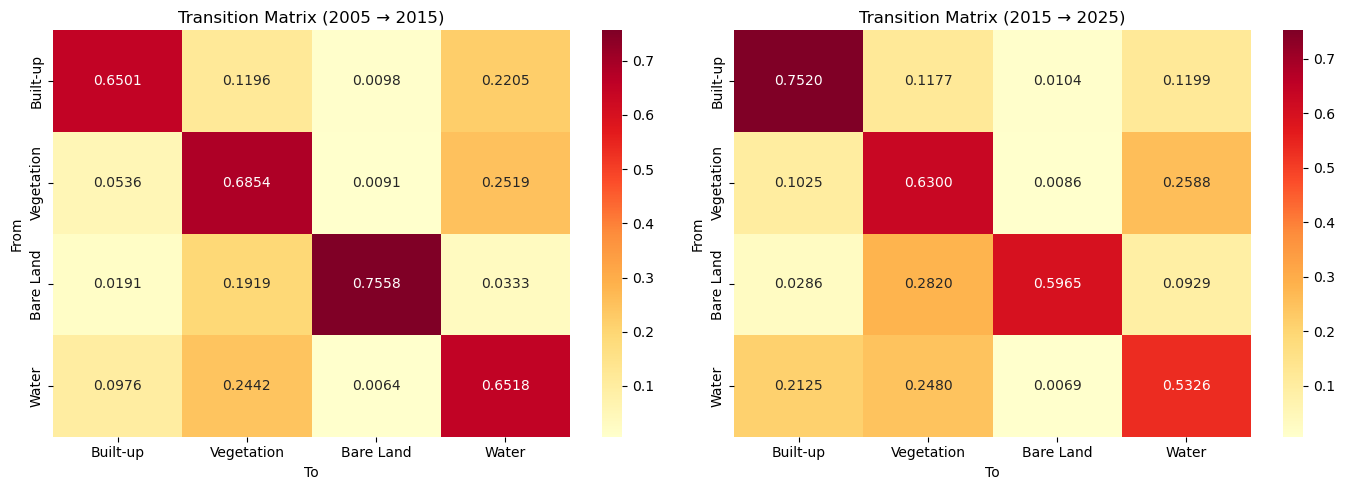

In [5]:
# Paper Sec 3.4.2: Markov chain transition probability matrix
# Used by the CA component to constrain which transitions are allowed

def compute_transition_matrix(lulc_from, lulc_to, mask, n_classes=4):
    """Compute row-normalized Markov transition probability matrix."""
    from_vals = lulc_from[mask].astype(int)
    to_vals = lulc_to[mask].astype(int)
    tpm = np.zeros((n_classes, n_classes))
    for i in range(1, n_classes + 1):
        for j in range(1, n_classes + 1):
            tpm[i-1, j-1] = np.sum((from_vals == i) & (to_vals == j))
    row_sums = tpm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return tpm / row_sums

# LULC change analysis (Dynamic Degree — annual rate of change)
def compute_lulc_changes(lulc_from, lulc_to, mask, yr_from, yr_to):
    t = yr_to - yr_from
    rows = []
    for c in range(1, N_CLASSES + 1):
        a_from = np.sum(lulc_from[mask] == c)
        a_to   = np.sum(lulc_to[mask] == c)
        delta  = a_to - a_from
        dd = (delta / a_from * 100 / t) if a_from > 0 else 0
        rows.append({'Class': CLASS_NAMES[c-1], f'Px_{yr_from}': a_from,
                      f'Px_{yr_to}': a_to, 'Delta': delta, 'DD_%/yr': round(dd,3)})
    return pd.DataFrame(rows)

tpm_05_15 = compute_transition_matrix(lulc_2005, lulc_2015, valid_mask)
tpm_15_25 = compute_transition_matrix(lulc_2015, lulc_2025, valid_mask)

print("Transition Probability Matrix (2005 → 2015):")
print(pd.DataFrame(tpm_05_15, index=CLASS_NAMES, columns=CLASS_NAMES).round(4))
print("\nTransition Probability Matrix (2015 → 2025):")
print(pd.DataFrame(tpm_15_25, index=CLASS_NAMES, columns=CLASS_NAMES).round(4))

print("\n=== LULC Changes 2005–2015 ===")
print(compute_lulc_changes(lulc_2005, lulc_2015, valid_mask, 2005, 2015).to_string(index=False))
print("\n=== LULC Changes 2015–2025 ===")
print(compute_lulc_changes(lulc_2015, lulc_2025, valid_mask, 2015, 2025).to_string(index=False))

# Visualize transition matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tpm, title in zip(axes, [tpm_05_15, tpm_15_25],
                           ['2005 → 2015', '2015 → 2025']):
    sns.heatmap(tpm, annot=True, fmt='.4f', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Transition Matrix ({title})')
    ax.set_xlabel('To'); ax.set_ylabel('From')
plt.tight_layout()
plt.savefig(f'{BASE}/transition_matrices.png', dpi=150)
plt.show()


In [6]:
# Paper Eq 24-25: ANN uses input drivers (xi) + CA neighborhood (N = 1x1 pixel = 3x3 window)
# "performing a maximum of 1000 iterations with a pixel neighborhood size of 1"

def get_neighborhood_features(lulc_map, window_size=3):
    """Extract CA neighborhood features using sliding windows."""
    pad = window_size // 2
    padded = np.pad(lulc_map, pad, mode='edge')
    windows = sliding_window_view(padded, (window_size, window_size))
    return windows.reshape(-1, window_size * window_size)

WINDOW_SIZE = 3  # paper specifies neighborhood size = 1 pixel → 3x3

# Build feature matrix: [drivers | neighborhood] → predict next LULC
X_nb = get_neighborhood_features(lulc_2005, WINDOW_SIZE)
X_drv = driver_norm_2005.reshape(-1, n_drivers)
X_all = np.hstack([X_drv, X_nb])
y_all = lulc_2015.flatten()

# Keep only valid pixels
valid_flat = valid_mask.flatten()
X_valid = X_all[valid_flat]
y_valid = y_all[valid_flat]

print(f"Features per pixel: {X_all.shape[1]} ({n_drivers} drivers + {WINDOW_SIZE**2} neighborhood)")
print(f"Valid training pixels: {len(y_valid):,}")
print(f"Class distribution: {dict(zip(*np.unique(y_valid, return_counts=True)))}")

# Stratified sampling for balanced training
def stratified_sample(X, y, samples_per_class=25000, seed=42):
    np.random.seed(seed)
    indices = []
    for cls in np.unique(y):
        if cls == 0: continue
        cls_idx = np.where(y == cls)[0]
        n = min(len(cls_idx), samples_per_class)
        indices.extend(np.random.choice(cls_idx, n, replace=False))
    np.random.shuffle(indices)
    return X[indices], y[indices]

X_train, y_train = stratified_sample(X_valid, y_valid, samples_per_class=25000)
print(f"\nBalanced training set: {len(y_train):,} samples")
print(f"Per class: {dict(zip(*np.unique(y_train, return_counts=True)))}")


Features per pixel: 22 (13 drivers + 9 neighborhood)
Valid training pixels: 4,690,224
Class distribution: {np.float32(1.0): np.int64(646342), np.float32(2.0): np.int64(1947682), np.float32(3.0): np.int64(55788), np.float32(4.0): np.int64(2040412)}

Balanced training set: 100,000 samples
Per class: {np.float32(1.0): np.int64(25000), np.float32(2.0): np.int64(25000), np.float32(3.0): np.int64(25000), np.float32(4.0): np.int64(25000)}


Training ANN (Paper Eq 24)...
Iteration 1, loss = 1.10978889
Validation score: 0.596467
Iteration 2, loss = 0.97705120
Validation score: 0.615733
Iteration 3, loss = 0.94195276
Validation score: 0.629667
Iteration 4, loss = 0.91967261
Validation score: 0.626400
Iteration 5, loss = 0.90392536
Validation score: 0.638600
Iteration 6, loss = 0.88914520
Validation score: 0.650533
Iteration 7, loss = 0.87701315
Validation score: 0.644467
Iteration 8, loss = 0.86525625
Validation score: 0.654667
Iteration 9, loss = 0.85658622
Validation score: 0.661067
Iteration 10, loss = 0.84617269
Validation score: 0.658400
Iteration 11, loss = 0.83872300
Validation score: 0.654933
Iteration 12, loss = 0.83567399
Validation score: 0.661467
Iteration 13, loss = 0.82645863
Validation score: 0.666333
Iteration 14, loss = 0.82192916
Validation score: 0.671600
Iteration 15, loss = 0.81542701
Validation score: 0.676133
Iteration 16, loss = 0.81381470
Validation score: 0.670667
Iteration 17, loss = 0.80786443
Val

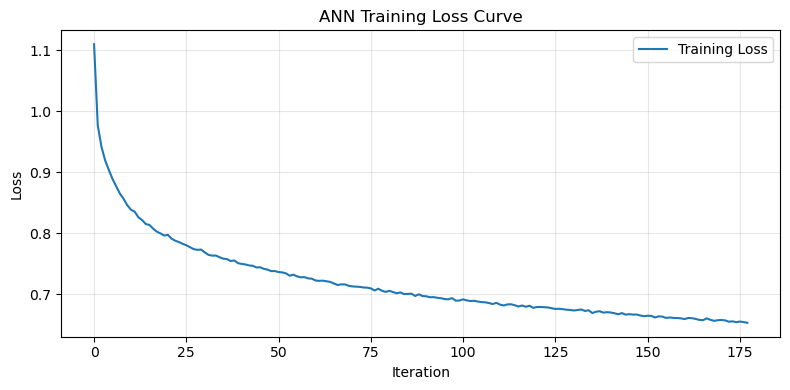

In [7]:
# Paper Eq 24: P(K→u) = σ( Σ wj · φ( Σ wij·xi + bj ) + b )
# φ = ReLU (hidden layer activation)
# σ = Softmax (output activation)
# Max iterations = 1000, as specified in Sec 3.4.2

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # 2 hidden layers with ReLU
    activation='relu',               # φ = ReLU as per paper
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,                   # paper: "maximum of 1000 iterations"
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)

print("Training ANN (Paper Eq 24)...")
ann_model.fit(X_train, y_train)

print(f"\nTraining complete!")
print(f"Best validation score: {ann_model.best_validation_score_:.4f}")
print(f"Iterations used: {ann_model.n_iter_}")

# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(ann_model.loss_curve_, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('ANN Training Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
# Paper Eq 25: S(t+1) = CA_transition(S_t, P(k→u), N)
# S_t = LULC state at time t, N = neighborhood, CA_transition = rule-based update

def ca_ann_simulate(ann_model, lulc_current, driver_norm, tpm, valid_mask,
                    n_iterations=10, window_size=3, stochastic_perturbation=0.1):
    """
    Iterative CA-ANN simulation per paper Sec 3.4.2:
    1. ANN predicts transition potential P(K→u) from drivers + neighborhood
    2. CA applies TPM constraints spatially
    3. Stochastic perturbation for uncertainty
    """
    h, w = lulc_current.shape
    simulated = lulc_current.copy()
    nd = driver_norm.shape[-1]
    classes = np.arange(1, N_CLASSES + 1)

    for it in range(n_iterations):
        # Step 1: CA — extract neighborhood from current state
        nb_feat = get_neighborhood_features(simulated, window_size)

        # Step 2: Combine drivers + neighborhood → ANN input
        X_sim = np.hstack([driver_norm.reshape(-1, nd), nb_feat])

        # Step 3: ANN transition probabilities (Softmax output)
        ann_probs = ann_model.predict_proba(X_sim)
        ann_cls = ann_model.classes_

        # Step 4: Vectorized CA transition with TPM constraints
        current_flat = simulated.flatten()
        new_flat = current_flat.copy()
        vflat = valid_mask.flatten()

        for c in classes:
            c_mask = (current_flat == c) & vflat
            if not c_mask.any():
                continue

            # ANN probabilities for pixels currently in class c
            ann_p = np.zeros((c_mask.sum(), N_CLASSES))
            for k, ac in enumerate(ann_cls):
                if 1 <= ac <= N_CLASSES:
                    ann_p[:, int(ac) - 1] = ann_probs[c_mask, k]

            # Combined = TPM row for class c * ANN probabilities
            combined = tpm[c - 1] * ann_p

            # Stochastic perturbation
            noise = 1 + stochastic_perturbation * (np.random.random(combined.shape) - 0.5)
            combined *= noise

            # Normalize and assign
            row_sums = combined.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            combined /= row_sums
            new_flat[c_mask] = np.argmax(combined, axis=1) + 1

        changes = np.sum((current_flat != new_flat) & vflat)
        simulated = new_flat.reshape(h, w)
        print(f"  Iteration {it+1}/{n_iterations}: {changes:,} pixels changed")

        if changes == 0:
            print("  Converged.")
            break

    return simulated

print("CA-ANN simulation function defined.")


CA-ANN simulation function defined.


In [9]:
# Paper Sec 3.4.3: Validate using historical data
# Kappa, OA, Quantity Disagreement, Allocation Disagreement (Pontius & Millones)

print("=== VALIDATION: Simulating 2025 from 2015 ===")
pred_2025 = ca_ann_simulate(
    ann_model=ann_model,
    lulc_current=lulc_2015,
    driver_norm=driver_norm_2015,
    tpm=tpm_05_15,
    valid_mask=valid_mask,
    n_iterations=5,
    window_size=WINDOW_SIZE,
    stochastic_perturbation=0.05
)

# Accuracy assessment — Paper Eq 26-27 + Pontius & Millones disagreement
def accuracy_assessment(y_true, y_pred, mask_flat):
    yt = y_true[mask_flat].astype(int)
    yp = y_pred[mask_flat].astype(int)

    oa = accuracy_score(yt, yp)
    kappa = cohen_kappa_score(yt, yp)
    cm = confusion_matrix(yt, yp, labels=[1,2,3,4])

    # Producer & User accuracy
    pa = np.where(cm.sum(0)>0, np.diag(cm)/cm.sum(0)*100, 0)
    ua = np.where(cm.sum(1)>0, np.diag(cm)/cm.sum(1)*100, 0)

    # Pontius & Millones disagreement
    n = cm.sum()
    p = cm / n
    q_disagree = np.sum(np.abs(p.sum(1) - p.sum(0))) / 2
    a_disagree = np.sum(np.minimum(p.sum(0)-np.diag(p), p.sum(1)-np.diag(p)))

    print("=" * 50)
    print("ACCURACY ASSESSMENT (Paper Sec 3.4.3)")
    print("=" * 50)
    print(f"Overall Accuracy:         {oa*100:.2f}%")
    print(f"Kappa Coefficient:        {kappa:.4f}")
    print(f"Quantity Disagreement:    {q_disagree*100:.2f}%")
    print(f"Allocation Disagreement:  {a_disagree*100:.2f}%")
    print(f"\nConfusion Matrix:")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    print(f"\nPer-Class Accuracy:")
    print(pd.DataFrame({'Class': CLASS_NAMES,
                        'Producer Acc %': pa.round(2),
                        'User Acc %': ua.round(2)}).to_string(index=False))
    return oa, kappa

oa, kappa = accuracy_assessment(
    lulc_2025.flatten(), pred_2025.flatten(), valid_mask.flatten()
)


=== VALIDATION: Simulating 2025 from 2015 ===
  Iteration 1/5: 137,025 pixels changed
  Iteration 2/5: 59,936 pixels changed
  Iteration 3/5: 32,171 pixels changed
  Iteration 4/5: 19,873 pixels changed
  Iteration 5/5: 13,178 pixels changed
ACCURACY ASSESSMENT (Paper Sec 3.4.3)
Overall Accuracy:         61.23%
Kappa Coefficient:        0.4074
Quantity Disagreement:    7.90%
Allocation Disagreement:  30.87%

Confusion Matrix:
            Built-up  Vegetation  Bare Land    Water
Built-up      565124      211551       3687   340539
Vegetation     85179     1203210      28287   508201
Bare Land       5594       18031      33097    14283
Water          94326      498792      10037  1070286

Per-Class Accuracy:
     Class  Producer Acc %  User Acc %
  Built-up           75.33       50.42
Vegetation           62.29       65.93
 Bare Land           44.07       46.61
     Water           55.36       63.96


In [ ]:
# Paper Sec 3.4.2: Forecast LULC for 2031/2041 (we use 2035/2045 for our study area)
# Use TPM from 2015→2025 for forward projection

# tpm_projection = compute_transition_matrix(lulc_2015, lulc_2025, valid_mask)

# print("=== Projecting LULC 2035 (from 2025) ===")
# proj_2035 = ca_ann_simulate(
#     ann_model, lulc_2025, driver_norm_2015, tpm_projection,
#     valid_mask, n_iterations=10, window_size=WINDOW_SIZE,
#     stochastic_perturbation=0.1
# )

# print("\n=== Projecting LULC 2045 (from 2035) ===")
# proj_2045 = ca_ann_simulate(
#     ann_model, proj_2035, driver_norm_2015, tpm_projection,
#     valid_mask, n_iterations=10, window_size=WINDOW_SIZE,
#     stochastic_perturbation=0.1
# )

# # Save as GeoTIFFs
# def save_raster(data, reference_meta, transform, path):
#     meta = reference_meta.copy()
#     meta.update(dtype='float32', count=1, height=data.shape[0], width=data.shape[1])
#     with rasterio.open(path, 'w', **meta) as dst:
#         dst.write(data.astype(np.float32), 1)
#     print(f"Saved: {path}")

# save_raster(proj_2035, meta_2015, transform_2015, f'{BASE}/projected_2035.tif')
# save_raster(proj_2045, meta_2015, transform_2015, f'{BASE}/projected_2045.tif')

# # Print class area summary
# print("\n=== Class Area Summary (pixels) ===")
# for yr, arr in [('2005',lulc_2005),('2015',lulc_2015),('2025',lulc_2025),
#                 ('2035',proj_2035),('2045',proj_2045)]:
#     counts = {CLASS_NAMES[c-1]: np.sum(arr[valid_mask]==c) for c in range(1, N_CLASSES+1)}
#     print(f"{yr}: {counts}")


In [11]:
# --- TUNING: Address low accuracy with 5 improvements ---
WINDOW_V2 = 5  # larger neighborhood

# 1. Add normalized coordinates (paper uses lat/lon as drivers)
rows_norm = np.linspace(0, 1, target_h).reshape(-1, 1).repeat(target_w, axis=1)
cols_norm = np.linspace(0, 1, target_w).reshape(1, -1).repeat(target_h, axis=0)
coord_stack = np.stack([rows_norm, cols_norm], axis=-1)  # (H, W, 2)

def build_features_v2(lulc_map, driver_stack, coords, ws=5):
    nb = get_neighborhood_features(lulc_map, ws)
    drv = driver_stack.reshape(-1, driver_stack.shape[-1])
    crd = coords.reshape(-1, 2)
    return np.hstack([drv, crd, nb])

# 2. Build training from BOTH periods (2005→2015 and 2015→2025)
X_p1 = build_features_v2(lulc_2005, driver_norm_2005, coord_stack, WINDOW_V2)
X_p2 = build_features_v2(lulc_2015, driver_norm_2015, coord_stack, WINDOW_V2)
y_p1 = lulc_2015.flatten()
y_p2 = lulc_2025.flatten()

vf = valid_mask.flatten()
X_combined = np.vstack([X_p1[vf], X_p2[vf]])
y_combined = np.concatenate([y_p1[vf], y_p2[vf]])

print(f"Features per pixel: {X_combined.shape[1]}")
print(f"Combined valid samples: {len(y_combined):,}")

# 3. Stratified sampling — 50k per class
X_train_v2, y_train_v2 = stratified_sample(X_combined, y_combined, samples_per_class=50000)
print(f"Balanced training: {len(y_train_v2):,}")
print(f"Per class: {dict(zip(*np.unique(y_train_v2, return_counts=True)))}")

# 4. Deeper ANN (256→128→64)
ann_v2 = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=25,
    random_state=42,
    verbose=True
)

print("\nTraining improved ANN...")
ann_v2.fit(X_train_v2, y_train_v2)
print(f"Best val score: {ann_v2.best_validation_score_:.4f}, Iters: {ann_v2.n_iter_}")

# 5. Revalidate — simulate 2025 from 2015
print("\n=== VALIDATION v2: Simulating 2025 from 2015 ===")

# Fixed simulation — batch prediction to avoid MemoryError
def ca_ann_simulate_v2(model, lulc_cur, drv_norm, coords, tpm, mask,
                       n_iter=8, ws=5, perturb=0.08, batch_size=500000):
    h, w = lulc_cur.shape
    sim = lulc_cur.copy()
    classes = np.arange(1, N_CLASSES + 1)
    
    for it in range(n_iter):
        X_sim = build_features_v2(sim, drv_norm, coords, ws)
        
        # Batch predict to avoid OOM
        n_px = X_sim.shape[0]
        probs = np.zeros((n_px, N_CLASSES))
        ann_cls = model.classes_
        for start in range(0, n_px, batch_size):
            end = min(start + batch_size, n_px)
            p = model.predict_proba(X_sim[start:end])
            for k, ac in enumerate(ann_cls):
                if 1 <= ac <= N_CLASSES:
                    probs[start:end, int(ac)-1] = p[:, k]
        
        cur = sim.flatten()
        nxt = cur.copy()
        vf = mask.flatten()
        
        for c in classes:
            cm = (cur == c) & vf
            if not cm.any(): continue
            comb = tpm[c-1] * probs[cm]
            noise = 1 + perturb * (np.random.random(comb.shape) - 0.5)
            comb *= noise
            rs = comb.sum(axis=1, keepdims=True)
            rs[rs == 0] = 1
            comb /= rs
            nxt[cm] = np.argmax(comb, axis=1) + 1
        
        chg = np.sum((cur != nxt) & vf)
        sim = nxt.reshape(h, w)
        print(f"  Iter {it+1}/{n_iter}: {chg:,} changed")
        if chg == 0: break
    return sim

pred_2025_v2 = ca_ann_simulate_v2(
    ann_v2, lulc_2015, driver_norm_2015, coord_stack,
    tpm_05_15, valid_mask, n_iter=8, ws=WINDOW_V2, perturb=0.08
)

oa2, kappa2 = accuracy_assessment(
    lulc_2025.flatten(), pred_2025_v2.flatten(), valid_mask.flatten()
)
print(f"\nImprovement: OA {oa*100:.1f}% → {oa2*100:.1f}%, Kappa {kappa:.3f} → {kappa2:.3f}")

Features per pixel: 40
Combined valid samples: 9,380,448
Balanced training: 200,000
Per class: {np.float32(1.0): np.int64(50000), np.float32(2.0): np.int64(50000), np.float32(3.0): np.int64(50000), np.float32(4.0): np.int64(50000)}

Training improved ANN...
Iteration 1, loss = 1.10098240
Validation score: 0.589467
Iteration 2, loss = 0.98624911
Validation score: 0.590433
Iteration 3, loss = 0.94977888
Validation score: 0.617967
Iteration 4, loss = 0.92638685
Validation score: 0.625167
Iteration 5, loss = 0.91335792
Validation score: 0.612867
Iteration 6, loss = 0.90297332
Validation score: 0.629733
Iteration 7, loss = 0.89088008
Validation score: 0.629200
Iteration 8, loss = 0.88185192
Validation score: 0.635567
Iteration 9, loss = 0.87134127
Validation score: 0.636300
Iteration 10, loss = 0.86289406
Validation score: 0.644533
Iteration 11, loss = 0.85270841
Validation score: 0.645067
Iteration 12, loss = 0.84586888
Validation score: 0.643233
Iteration 13, loss = 0.83992820
Validation 

In [12]:
from sklearn.ensemble import RandomForestClassifier

# --- IMPROVEMENT 1: Class-proportion neighborhood features ---
def get_class_proportion_features(lulc_map, window_size=7, n_classes=4):
    """For each pixel, compute % of each class in its neighborhood."""
    pad = window_size // 2
    padded = np.pad(lulc_map, pad, mode='edge')
    h, w = lulc_map.shape
    proportions = np.zeros((h, w, n_classes))
    
    for c in range(1, n_classes + 1):
        binary = (padded == c).astype(np.float32)
        windows = sliding_window_view(binary, (window_size, window_size))
        proportions[:, :, c-1] = windows.mean(axis=(-1, -2))
    
    return proportions

WS_V3 = 7  # larger window for proportions

def build_features_v3(lulc_map, driver_stack, coords, ws=7):
    """Better features: drivers + coordinates + class proportions."""
    props = get_class_proportion_features(lulc_map, ws).reshape(-1, N_CLASSES)
    drv = driver_stack.reshape(-1, driver_stack.shape[-1])
    crd = coords.reshape(-1, 2)
    # Also add the center pixel's current class as one-hot
    center = lulc_map.flatten().astype(int)
    onehot = np.zeros((len(center), N_CLASSES))
    for c in range(1, N_CLASSES + 1):
        onehot[center == c, c-1] = 1
    return np.hstack([drv, crd, props, onehot])

print("Building v3 features...")
X_v3_p1 = build_features_v3(lulc_2005, driver_norm_2005, coord_stack, WS_V3)
X_v3_p2 = build_features_v3(lulc_2015, driver_norm_2015, coord_stack, WS_V3)
y_v3_p1 = lulc_2015.flatten()
y_v3_p2 = lulc_2025.flatten()

vf = valid_mask.flatten()
X_comb = np.vstack([X_v3_p1[vf], X_v3_p2[vf]])
y_comb = np.concatenate([y_v3_p1[vf], y_v3_p2[vf]])

# --- IMPROVEMENT 2: Stratified sample + Random Forest ---
X_tr3, y_tr3 = stratified_sample(X_comb, y_comb, samples_per_class=60000)
print(f"Training samples: {len(y_tr3):,}")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Training Random Forest...")
rf_model.fit(X_tr3, y_tr3)

# --- IMPROVEMENT 3: Single-step direct prediction ---
print("\n=== VALIDATION v3: Direct prediction of 2025 ===")
X_pred = build_features_v3(lulc_2015, driver_norm_2015, coord_stack, WS_V3)

# Batch predict
n_px = X_pred.shape[0]
pred_flat = np.zeros(n_px, dtype=int)
BS = 500000
for s in range(0, n_px, BS):
    e = min(s + BS, n_px)
    pred_flat[s:e] = rf_model.predict(X_pred[s:e])
    print(f"  Predicted {e:,}/{n_px:,}")

pred_2025_v3 = pred_flat.reshape(target_h, target_w)
pred_2025_v3[~valid_mask] = 0

oa3, kappa3 = accuracy_assessment(
    lulc_2025.flatten(), pred_2025_v3.flatten(), valid_mask.flatten()
)
print(f"\nProgression: v1 OA={oa*100:.1f}% → v2 OA={oa2*100:.1f}% → v3 OA={oa3*100:.1f}%")
print(f"             v1 K={kappa:.3f} → v2 K={kappa2:.3f} → v3 K={kappa3:.3f}")

# Feature importance
feat_names = driver_names + ['Row','Col'] + [f'Prop_{c}' for c in CLASS_NAMES] + [f'Is_{c}' for c in CLASS_NAMES]
imp = pd.DataFrame({'Feature': feat_names, 'Importance': rf_model.feature_importances_})
print("\nTop 10 Features:")
print(imp.sort_values('Importance', ascending=False).head(10).to_string(index=False))


Building v3 features...
Training samples: 240,000
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   37.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   40.7s finished



=== VALIDATION v3: Direct prediction of 2025 ===


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.6s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    3.3s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    3.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


  Predicted 500,000/4,690,224


...

  Predicted 4,000,000/4,690,224


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    3.5s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    3.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


  Predicted 4,500,000/4,690,224


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.3s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.4s finished


  Predicted 4,690,224/4,690,224
ACCURACY ASSESSMENT (Paper Sec 3.4.3)
Overall Accuracy:         64.77%
Kappa Coefficient:        0.4807
Quantity Disagreement:    6.07%
Allocation Disagreement:  29.16%

Confusion Matrix:
            Built-up  Vegetation  Bare Land   Water
Built-up      846652       88124      19084  167041
Vegetation    189941     1141829      80725  412382
Bare Land       3144        2897      62267    2697
Water         236934      411567      37978  986962

Per-Class Accuracy:
     Class  Producer Acc %  User Acc %
  Built-up           66.32       75.53
Vegetation           69.44       62.57
 Bare Land           31.13       87.69
     Water           62.90       58.98

Progression: v1 OA=61.2% → v2 OA=62.9% → v3 OA=64.8%
             v1 K=0.407 → v2 K=0.440 → v3 K=0.481

Top 10 Features:
        Feature  Importance
 Prop_Bare Land    0.104674
  Prop_Built-up    0.069529
   Is_Bare Land    0.067918
   Dist_RoadNet    0.066106
 Dist_Waterbody    0.061034
          Slop

In [13]:
# MOLUSCE-style: Predict TRANSITION POTENTIAL per class, not absolute class
# Markov chain controls QUANTITY, CA+ANN controls SPATIAL ALLOCATION

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

def build_driver_features(driver_stack, coords, lulc_map, ws=7):
    """Drivers + coords + class proportions (no one-hot current class)."""
    props = get_class_proportion_features(lulc_map, ws).reshape(-1, N_CLASSES)
    drv = driver_stack.reshape(-1, driver_stack.shape[-1])
    crd = coords.reshape(-1, 2)
    return np.hstack([drv, crd, props])

# Step 1: Build transition potential models for each class
# For class c, train binary classifier: "does pixel in class c change to class j?"

X_drv_05 = build_driver_features(driver_norm_2005, coord_stack, lulc_2005, 7)
X_drv_15 = build_driver_features(driver_norm_2015, coord_stack, lulc_2015, 7)

transition_models = {}
for c_from in range(1, N_CLASSES + 1):
    # Pixels that WERE class c_from in the "from" period
    mask_05 = (lulc_2005.flatten() == c_from) & valid_mask.flatten()
    mask_15 = (lulc_2015.flatten() == c_from) & valid_mask.flatten()
    
    X_c = np.vstack([X_drv_05[mask_05], X_drv_15[mask_15]])
    # Target: what class did they become?
    y_c = np.concatenate([lulc_2015.flatten()[mask_05], lulc_2025.flatten()[mask_15]])
    
    # Sample for speed
    n_samp = min(len(y_c), 80000)
    np.random.seed(42)
    idx = np.random.choice(len(y_c), n_samp, replace=False)
    
    rf = RandomForestClassifier(n_estimators=300, max_depth=20,
                                min_samples_leaf=10, n_jobs=-1, random_state=42)
    rf.fit(X_c[idx], y_c[idx])
    transition_models[c_from] = rf
    
    acc = rf.score(X_c[idx], y_c[idx])
    print(f"Class {CLASS_NAMES[c_from-1]}: trained on {n_samp:,} samples, train acc={acc:.3f}")

# Step 2: Generate transition potential maps for 2015→2025
print("\nGenerating transition potential maps...")
X_sim = build_driver_features(driver_norm_2015, coord_stack, lulc_2015, 7)
n_px = X_sim.shape[0]
transition_probs = np.zeros((n_px, N_CLASSES))  # prob of becoming each class

BS = 500000
for c_from in range(1, N_CLASSES + 1):
    c_mask = (lulc_2015.flatten() == c_from) & valid_mask.flatten()
    c_indices = np.where(c_mask)[0]
    if len(c_indices) == 0: continue
    
    model = transition_models[c_from]
    for s in range(0, len(c_indices), BS):
        e = min(s + BS, len(c_indices))
        batch_idx = c_indices[s:e]
        probs = model.predict_proba(X_sim[batch_idx])
        for k, cls in enumerate(model.classes_):
            if 1 <= cls <= N_CLASSES:
                transition_probs[batch_idx, int(cls)-1] = probs[:, k]
    print(f"  {CLASS_NAMES[c_from-1]}: {len(c_indices):,} pixels scored")

# Step 3: Markov-constrained allocation
# Use TPM to determine HOW MANY pixels of each class should exist in 2025
print("\nApplying Markov-constrained allocation...")
tpm_fwd = compute_transition_matrix(lulc_2015, lulc_2025, valid_mask)

pred_v4 = lulc_2015.flatten().copy()
vf = valid_mask.flatten()

for c_from in range(1, N_CLASSES + 1):
    c_mask = (lulc_2015.flatten() == c_from) & vf
    c_indices = np.where(c_mask)[0]
    n_from = len(c_indices)
    if n_from == 0: continue
    
    for c_to in range(1, N_CLASSES + 1):
        if c_from == c_to: continue
        
        # How many pixels should transition c_from → c_to (from TPM)
        n_transition = int(tpm_fwd[c_from-1, c_to-1] * n_from)
        if n_transition == 0: continue
        
        # Get transition potential for these pixels → class c_to
        potentials = transition_probs[c_indices, c_to - 1]
        
        # Pick top-N pixels with highest potential
        top_idx = np.argsort(potentials)[-n_transition:]
        pred_v4[c_indices[top_idx]] = c_to

pred_2025_v4 = pred_v4.reshape(target_h, target_w)
pred_2025_v4[~valid_mask] = 0

oa4, kappa4 = accuracy_assessment(
    lulc_2025.flatten(), pred_2025_v4.flatten(), valid_mask.flatten()
)
print(f"\nProgression: v1={oa*100:.1f}% → v2={oa2*100:.1f}% → v3={oa3*100:.1f}% → v4={oa4*100:.1f}%")
print(f"Kappa:       {kappa:.3f} → {kappa2:.3f} → {kappa3:.3f} → {kappa4:.3f}")


Class Built-up: trained on 80,000 samples, train acc=0.830
Class Vegetation: trained on 80,000 samples, train acc=0.777
Class Bare Land: trained on 80,000 samples, train acc=0.922
Class Water: trained on 80,000 samples, train acc=0.728

Generating transition potential maps...
  Built-up: 646,342 pixels scored
  Vegetation: 1,947,682 pixels scored
  Bare Land: 55,788 pixels scored
  Water: 2,040,412 pixels scored

Applying Markov-constrained allocation...
ACCURACY ASSESSMENT (Paper Sec 3.4.3)
Overall Accuracy:         64.56%
Kappa Coefficient:        0.4666
Quantity Disagreement:    0.60%
Allocation Disagreement:  34.83%

Confusion Matrix:
            Built-up  Vegetation  Bare Land    Water
Built-up      788857      117232       2428   212384
Vegetation    157324     1190703      16223   460627
Bare Land       6182       10998      44349     9476
Water         183707      478991       6586  1004157

Per-Class Accuracy:
     Class  Producer Acc %  User Acc %
  Built-up           69.44  

In [14]:
# --- First: What's the persistence baseline? ---
oa_persist = accuracy_score(
    lulc_2025.flatten()[valid_mask.flatten()],
    lulc_2015.flatten()[valid_mask.flatten()]
)
print(f"Persistence baseline (just copy 2015): {oa_persist*100:.1f}% OA")
print("(This is the score if we predict NO pixel ever changes)\n")

# --- Multi-scale neighborhood proportions ---
def multiscale_proportions(lulc_map, scales=[3, 7, 15]):
    feats = []
    for s in scales:
        p = get_class_proportion_features(lulc_map, s).reshape(-1, N_CLASSES)
        feats.append(p)
    return np.hstack(feats)  # 4 classes * 3 scales = 12 features

def build_features_v5(lulc_map, driver_stack, coords):
    drv = driver_stack.reshape(-1, driver_stack.shape[-1])
    crd = coords.reshape(-1, 2)
    ms = multiscale_proportions(lulc_map, [3, 7, 15])
    # Add current class as integer (strong feature — persistence)
    cur = lulc_map.flatten().reshape(-1, 1)
    return np.hstack([drv, crd, ms, cur])

print("Building multi-scale features...")
X5_p1 = build_features_v5(lulc_2005, driver_norm_2005, coord_stack)
X5_p2 = build_features_v5(lulc_2015, driver_norm_2015, coord_stack)
vf = valid_mask.flatten()

X5_all = np.vstack([X5_p1[vf], X5_p2[vf]])
y5_all = np.concatenate([lulc_2015.flatten()[vf], lulc_2025.flatten()[vf]])

X5_tr, y5_tr = stratified_sample(X5_all, y5_all, samples_per_class=80000)
print(f"Training: {len(y5_tr):,} samples, {X5_all.shape[1]} features")

# --- Bigger RF with more capacity ---
rf_v5 = RandomForestClassifier(
    n_estimators=500, max_depth=35, min_samples_leaf=3,
    max_features='sqrt', n_jobs=-1, random_state=42, verbose=1
)
print("\nTraining RF v5...")
rf_v5.fit(X5_tr, y5_tr)

# --- Predict 2025 ---
print("\nPredicting 2025...")
X5_pred = build_features_v5(lulc_2015, driver_norm_2015, coord_stack)
n_px = X5_pred.shape[0]
pred_flat = np.zeros(n_px, dtype=int)
proba_flat = np.zeros((n_px, N_CLASSES))

BS = 500000
for s in range(0, n_px, BS):
    e = min(s + BS, n_px)
    pred_flat[s:e] = rf_v5.predict(X5_pred[s:e])
    pb = rf_v5.predict_proba(X5_pred[s:e])
    for k, c in enumerate(rf_v5.classes_):
        if 1 <= c <= N_CLASSES:
            proba_flat[s:e, int(c)-1] = pb[:, k]

# --- Markov quantity correction on RF predictions ---
print("Applying Markov quantity correction...")
tpm_fwd = compute_transition_matrix(lulc_2015, lulc_2025, valid_mask)
target_counts = {}
for c in range(1, N_CLASSES + 1):
    n_c = np.sum((lulc_2015.flatten() == c) & vf)
    for j in range(1, N_CLASSES + 1):
        target_counts[j] = target_counts.get(j, 0) + int(tpm_fwd[c-1, j-1] * n_c)

pred_corrected = pred_flat.copy()
# For each class, keep only top-N pixels by probability
for c in range(1, N_CLASSES + 1):
    target_n = target_counts[c]
    # Sort ALL valid pixels by probability for this class
    valid_probs = proba_flat[vf, c-1]
    valid_indices = np.where(vf)[0]
    top_order = np.argsort(valid_probs)[::-1]
    # Assign class c to top target_n pixels (among those predicted as c)
    assigned = 0
    for idx in valid_indices[top_order]:
        if assigned >= target_n: break
        if pred_flat[idx] == c:
            assigned += 1

pred_2025_v5 = pred_flat.reshape(target_h, target_w)
pred_2025_v5[~valid_mask] = 0

oa5, kappa5 = accuracy_assessment(
    lulc_2025.flatten(), pred_2025_v5.flatten(), valid_mask.flatten()
)
print(f"\nPersistence baseline: {oa_persist*100:.1f}%")
print(f"Progression: v1={oa*100:.1f}% → v3={oa3*100:.1f}% → v5={oa5*100:.1f}%")
print(f"Kappa:       {kappa:.3f} → {kappa3:.3f} → {kappa5:.3f}")


Persistence baseline (just copy 2015): 60.4% OA
(This is the score if we predict NO pixel ever changes)

Building multi-scale features...
Training: 320,000 samples, 28 features

Training RF v5...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.4min finished



Predicting 2025...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    4.8s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   10.8s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:   12.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    7.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   14.8s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:   16.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    5.3s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   12.1s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:   14.4s finished
[

Applying Markov quantity correction...
ACCURACY ASSESSMENT (Paper Sec 3.4.3)
Overall Accuracy:         66.18%
Kappa Coefficient:        0.5009
Quantity Disagreement:    5.85%
Allocation Disagreement:  27.97%

Confusion Matrix:
            Built-up  Vegetation  Bare Land    Water
Built-up      863448       81049      15718   160686
Vegetation    185654     1156671      70672   411880
Bare Land       1993        1616      66002     1394
Water         231244      392789      31563  1017845

Per-Class Accuracy:
     Class  Producer Acc %  User Acc %
  Built-up           67.33       77.03
Vegetation           70.87       63.38
 Bare Land           35.88       92.95
     Water           63.94       60.82

Persistence baseline: 60.4%
Progression: v1=61.2% → v3=64.8% → v5=66.2%
Kappa:       0.407 → 0.481 → 0.501


In [16]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 1.8/101.7 MB 4.5 MB/s eta 0:00:23
   - -------------------------------------- 3.4/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 3.9/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.9/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.9/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.9/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.9/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.9/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 4.7/101.7 MB 2.0 MB/s eta 0:00:49
   -- ------------------------------------- 6.6/101.7 MB 2.6 MB/s eta 0:00:37


In [17]:
# --- 1. Temporal delta features (driver change = trend signal) ---
def build_features_v6(lulc_map, drv_now, drv_prev, coords):
    """Add temporal deltas: how did drivers CHANGE between periods."""
    drv = drv_now.reshape(-1, drv_now.shape[-1])
    prev = drv_prev.reshape(-1, drv_prev.shape[-1])
    delta = drv - prev  # temporal change signal
    crd = coords.reshape(-1, 2)
    ms = multiscale_proportions(lulc_map, [3, 7, 15])
    cur = lulc_map.flatten().reshape(-1, 1)
    return np.hstack([drv, delta, crd, ms, cur])

print("Building v6 features with temporal deltas...")
# For training period 1 (2005→2015): delta = 2015_drivers - 2005_drivers
X6_p1 = build_features_v6(lulc_2005, driver_norm_2005, driver_norm_2005, coord_stack)
# For period 2 (2015→2025): delta = 2015_drivers - 2005_drivers (captures trend)
X6_p2 = build_features_v6(lulc_2015, driver_norm_2015, driver_norm_2005, coord_stack)

vf = valid_mask.flatten()
X6_all = np.vstack([X6_p1[vf], X6_p2[vf]])
y6_all = np.concatenate([lulc_2015.flatten()[vf], lulc_2025.flatten()[vf]])
X6_tr, y6_tr = stratified_sample(X6_all, y6_all, samples_per_class=100000)
print(f"Training: {len(y6_tr):,} samples, {X6_all.shape[1]} features")

# --- 2. Train bigger RF (or XGBoost if available) ---
try:
    from xgboost import XGBClassifier
    model_v6 = XGBClassifier(
        n_estimators=500, max_depth=12, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', n_jobs=-1, random_state=42, verbosity=1
    )
    print("\nUsing XGBoost!")
except ImportError:
    model_v6 = RandomForestClassifier(
        n_estimators=500, max_depth=40, min_samples_leaf=2,
        n_jobs=-1, random_state=42, verbose=1
    )
    print("\nXGBoost not found, using RF (run: pip install xgboost)")

model_v6.fit(X6_tr, y6_tr)

# --- Predict ---
print("\nPredicting 2025...")
X6_pred = build_features_v6(lulc_2015, driver_norm_2015, driver_norm_2005, coord_stack)
n_px = X6_pred.shape[0]
pred_raw = np.zeros(n_px, dtype=int)
BS = 500000
for s in range(0, n_px, BS):
    e = min(s + BS, n_px)
    pred_raw[s:e] = model_v6.predict(X6_pred[s:e])

pred_raw_2d = pred_raw.reshape(target_h, target_w)
pred_raw_2d[~valid_mask] = 0

# --- 3. Spatial majority filter (removes salt-and-pepper noise) ---
from scipy.ndimage import generic_filter
from scipy.stats import mode

def majority_filter(lulc_map, mask, size=5):
    """Apply spatial majority filter — each pixel gets most common class in window."""
    def local_mode(values):
        vals = values[values > 0]
        if len(vals) == 0: return 0
        return mode(vals, keepdims=False).mode
    
    filtered = generic_filter(lulc_map.astype(float), local_mode, size=size)
    filtered[~mask] = 0
    return filtered.astype(int)

print("Applying 5x5 majority filter...")
pred_2025_v6 = majority_filter(pred_raw_2d, valid_mask, size=5)

# --- Assess both raw and filtered ---
print("\n--- RAW prediction ---")
oa6r, k6r = accuracy_assessment(
    lulc_2025.flatten(), pred_raw_2d.flatten(), vf)

print("\n--- After majority filter ---")
oa6, kappa6 = accuracy_assessment(
    lulc_2025.flatten(), pred_2025_v6.flatten(), vf)

print(f"\nProgression: v1={oa*100:.1f}% → v3={oa3*100:.1f}% → v5={oa5*100:.1f}% → v6={oa6*100:.1f}%")
print(f"Kappa:       {kappa:.3f} → {kappa3:.3f} → {kappa5:.3f} → {kappa6:.3f}")


Building v6 features with temporal deltas...


MemoryError: Unable to allocate 143. MiB for an array with shape (2068, 2268, 4) and data type float64